In [1]:
import sys, subprocess, os, gzip, shutil, warnings, textwrap
warnings.filterwarnings("ignore")

packages = [
    "numpy", "pandas", "scipy", "scikit-learn",
    "matplotlib", "requests", "GEOparse"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

import numpy as np
import pandas as pd
import requests
import GEOparse
import matplotlib.pyplot as plt

from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GSE_ID = "GSE211567"

BASE_DIR = os.path.abspath("./GSE211567_LMCE_Project")
DATA_DIR = os.path.join(BASE_DIR, "data")
OUT_DIR = os.path.join(BASE_DIR, "outputs")
FIG_DIR = os.path.join(OUT_DIR, "figures")

for d in [BASE_DIR, DATA_DIR, OUT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project folder:", BASE_DIR)

Project folder: /Users/rifaldyfajar/GSE211567_LMCE_Project


In [4]:
print("Downloading GEO metadata...")

gse = GEOparse.get_GEO(
    geo=GSE_ID,
    destdir=DATA_DIR,
    annotate_gpl=False
)

rows = []

for gsm_id, gsm in gse.gsms.items():
    row = {
        "geo_accession": gsm_id,
        "title": gsm.metadata.get("title", [""])[0],
        "source_name": gsm.metadata.get("source_name_ch1", [""])[0],
        "organism": gsm.metadata.get("organism_ch1", [""])[0],
    }
    
    for item in gsm.metadata.get("characteristics_ch1", []):
        if ":" in item:
            key, val = item.split(":", 1)
            key = key.strip().lower().replace(" ", "_").replace("-", "_")
            row[key] = val.strip()
    
    rows.append(row)

meta = pd.DataFrame(rows)
meta.to_csv(os.path.join(OUT_DIR, "metadata_raw.csv"), index=False)

print("Metadata shape:", meta.shape)
display(meta.head())
print(meta.columns.tolist())

03-Jul-2026 13:58:12 DEBUG utils - Directory /Users/rifaldyfajar/GSE211567_LMCE_Project/data already exists. Skipping.
03-Jul-2026 13:58:12 INFO GEOparse - File already exist: using local version.
03-Jul-2026 13:58:12 INFO GEOparse - Parsing /Users/rifaldyfajar/GSE211567_LMCE_Project/data/GSE211567_family.soft.gz: 
03-Jul-2026 13:58:12 DEBUG GEOparse - DATABASE: GeoMiame
03-Jul-2026 13:58:12 DEBUG GEOparse - SERIES: GSE211567
03-Jul-2026 13:58:12 DEBUG GEOparse - PLATFORM: GPL16791
03-Jul-2026 13:58:12 DEBUG GEOparse - PLATFORM: GPL24676
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479889
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479890
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479891
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479892
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479893
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479894
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479895
03-Jul-2026 13:58:12 DEBUG GEOparse - SAMPLE: GSM6479896


03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480006
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480007
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480008
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480009
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480010
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480011
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480012
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480013
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480014
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480015
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480016
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480017
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480018
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480019
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480020
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480021
03-Jul-2026 13:58:13 DEBUG GEOparse - SAMPLE: GSM6480022
03-Jul-2026 13:58:13 DEBUG GEOp

Metadata shape: (291, 11)


,geo_accession,title,source_name,organism,sequencing_batch,gender,age,race,site,infection_type,pathogen
0,GSM6479889,136848_S8,whole blood,Homo sapiens,2,male,42,White,United_States,Bacterial,Streptococcus
1,GSM6479890,286605_S4,whole blood,Homo sapiens,2,female,62,White,United_States,Noninfection,Noninfection
2,GSM6479891,286615_S36,whole blood,Homo sapiens,2,female,53,White,United_States,Noninfection,Noninfection
3,GSM6479892,286671_S5,whole blood,Homo sapiens,2,male,23,White,United_States,Bacterial,Streptococcus
4,GSM6479893,286678_S37,whole blood,Homo sapiens,2,female,74,White,United_States,Noninfection,Noninfection


['geo_accession', 'title', 'source_name', 'organism', 'sequencing_batch', 'gender', 'age', 'race', 'site', 'infection_type', 'pathogen']


In [11]:
# CELL 3 — Download expression matrix FIXED with retry

import os, gzip, shutil, time, requests

norm_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE211nnn/GSE211567/suppl/GSE211567_normData_discovery_2021MAR24.txt.gz"

gz_path = os.path.join(DATA_DIR, "GSE211567_normData_discovery_2021MAR24.txt.gz")
txt_path = gz_path.replace(".gz", "")

# Remove broken previous files
for p in [gz_path, txt_path]:
    if os.path.exists(p):
        os.remove(p)
        print("Removed old file:", p)

def download_with_retry(url, out_path, max_retry=5):
    for attempt in range(1, max_retry + 1):
        try:
            print(f"Download attempt {attempt}/{max_retry}...")
            with requests.get(url, stream=True, timeout=600) as r:
                r.raise_for_status()
                with open(out_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

            size_mb = os.path.getsize(out_path) / (1024 * 1024)
            print(f"Downloaded size: {size_mb:.2f} MB")

            if size_mb < 40:
                raise ValueError("Downloaded file is too small; likely incomplete.")

            return True

        except Exception as e:
            print("Download failed:", e)
            if os.path.exists(out_path):
                os.remove(out_path)
            time.sleep(5)

    raise RuntimeError("Download failed after multiple attempts.")

download_with_retry(norm_url, gz_path)

print("Testing gzip integrity...")
with gzip.open(gz_path, "rb") as fin:
    fin.read(1024)

print("Decompressing...")
with gzip.open(gz_path, "rb") as fin, open(txt_path, "wb") as fout:
    shutil.copyfileobj(fin, fout)

print("Expression file ready:", txt_path)
print("TXT size MB:", os.path.getsize(txt_path) / (1024 * 1024))

Removed old file: /Users/rifaldyfajar/GSE211567_LMCE_Project/data/GSE211567_normData_discovery_2021MAR24.txt.gz
Removed old file: /Users/rifaldyfajar/GSE211567_LMCE_Project/data/GSE211567_normData_discovery_2021MAR24.txt
Download attempt 1/5...
Downloaded size: 46.04 MB
Testing gzip integrity...
Decompressing...
Expression file ready: /Users/rifaldyfajar/GSE211567_LMCE_Project/data/GSE211567_normData_discovery_2021MAR24.txt
TXT size MB: 98.14269065856934


In [31]:
# ======================================================
# CELL 4
# Inspect expression matrix
# ======================================================

expr_raw = pd.read_csv(
    txt_path,
    sep="\t",
    low_memory=False
)

print("="*80)
print("Shape")
print(expr_raw.shape)

print("="*80)
print("Columns")
print(expr_raw.columns.tolist())

print("="*80)
print("First 5 rows")
display(expr_raw.head())

print("="*80)
print("Dtypes")
print(expr_raw.dtypes)

print("="*80)
print("Random rows")
display(expr_raw.sample(5))

Shape
(19999, 292)
Columns
['Unnamed: 0', 'DU16-02S0004801', 'DU14-03S0000021', 'DU16-02S0004851', 'DU10-01S0000004', 'DU09-03S0000020', 'DU09-03S0000018', 'DU16-02S0004883', 'DU09-03S0000030', 'DU16-02S0004790', 'DU09-03S0000031', 'DU10-01S0000025', 'DU09-03S0000040', 'DU10-01S0000020', 'DU16-02S0004787', 'DU09-03S0000037', 'DU16-02S0004805', 'DU10-01S0000027', 'DU09-03S0000029', 'DU16-02S0004847', 'DU09-03S0000028', 'DU09-03S0000021', 'DU16-02S0004799', 'DU09-03S0000019', 'DU16-02S0004873', 'DU16-02S0004795', 'DU16-02S0004813', 'DU16-02S0004822', 'DU09-03S0000013', 'DU14-03S0000002', 'DU09-03S0000016', 'DU16-02S0004890', 'DU09-03S0000004', 'DU16-02S0004892', 'DU16-02S0004825', 'DU16-02S0004766', 'DU09-03S0000038', 'DU16-02S0004831', 'DU16-02S0004882', 'DU14-03S0000018', 'DU16-02S0004860', 'DU10-01S0000014', 'DU09-03S0000032', 'DU16-02S0004818', 'DU16-02S0004786', 'DU16-02S0004893', 'DU16-02S0004826', 'DU09-03S0000009', 'DU16-02S0004770', 'DU10-01S0000005', 'DU16-02S0004819', 'DU10-01

,Unnamed: 0,DU16-02S0004801,DU14-03S0000021,DU16-02S0004851,DU10-01S0000004,DU09-03S0000020,DU09-03S0000018,DU16-02S0004883,DU09-03S0000030,DU16-02S0004790,...,DU10-01S0000099,DU14-03S0035204,DU14-03S0000940,DU16-02S0003200,DU16-02S0003149,DU16-02S0003115,DU16-02S0003122,DU16-02S0003150,DU16-02S0003129,DU14-03S0035201
0,NM_001353689,-1.170164,-5.000086,0.008937,0.901532,-1.151759,-0.924109,-1.324967,-1.533156,-0.074342,...,-2.018000,0.625189,-2.123128,-3.169405,0.445538,-3.534986,-1.135050,0.694633,-3.338354,-0.839165
1,NM_001286458,4.745173,5.330436,5.152528,3.526814,2.073656,1.844830,2.658176,4.769457,3.910811,...,5.516564,3.647183,4.279863,4.469396,4.505332,3.820860,-0.130466,4.528697,4.207539,4.596704
2,NM_001323969,2.992444,2.282223,1.761961,0.736375,1.713135,3.288947,1.355881,1.967345,2.035903,...,3.263335,2.611388,2.538995,1.769739,3.033823,-0.028182,-0.846614,2.291906,1.526570,2.923018
3,NM_001303059,4.352302,3.373396,3.094683,1.861572,3.060830,3.048146,3.293998,2.719043,3.317741,...,3.595435,4.123527,3.893901,3.432782,4.085660,3.334499,-0.689971,4.035432,3.428876,3.803851
4,NM_001286830,3.031611,0.820535,0.028019,0.921863,2.364706,1.909356,1.526039,2.165859,2.257533,...,-0.885393,1.991747,2.132550,1.087077,1.753282,-2.501807,-0.834830,1.493993,1.504518,0.895628


Dtypes
Unnamed: 0          object
DU16-02S0004801    float64
DU14-03S0000021    float64
DU16-02S0004851    float64
DU10-01S0000004    float64
                    ...   
DU16-02S0003115    float64
DU16-02S0003122    float64
DU16-02S0003150    float64
DU16-02S0003129    float64
DU14-03S0035201    float64
Length: 292, dtype: object
Random rows


,Unnamed: 0,DU16-02S0004801,DU14-03S0000021,DU16-02S0004851,DU10-01S0000004,DU09-03S0000020,DU09-03S0000018,DU16-02S0004883,DU09-03S0000030,DU16-02S0004790,...,DU10-01S0000099,DU14-03S0035204,DU14-03S0000940,DU16-02S0003200,DU16-02S0003149,DU16-02S0003115,DU16-02S0003122,DU16-02S0003150,DU16-02S0003129,DU14-03S0035201
10650,NR_152606,0.805986,-0.891777,1.814052,1.911367,0.697378,2.055022,0.927672,0.811750,0.812874,...,0.343468,1.486863,0.024534,1.259085,1.396602,2.359891,3.739331,1.590233,-3.275653,0.785717
2041,NM_015993,-3.815488,-7.821536,-0.177021,-1.309980,-3.066336,-4.320493,-8.326180,-7.845204,-4.722787,...,0.414290,-5.719982,-5.184219,-3.913924,-0.387387,-4.387668,-2.298270,1.640654,-4.132859,-4.997008
8668,NR_138026,-1.364525,-0.797200,1.022802,1.499006,1.643431,0.474693,1.181078,-1.252930,0.315026,...,0.562693,0.715770,-4.091456,0.372054,1.047002,1.937204,-2.038750,1.589755,0.750462,0.117523
1114,NM_001316897,-1.535919,-0.678454,-0.352470,-1.017034,-2.623520,-2.190794,-1.886895,-0.599944,-0.858133,...,-0.607890,-1.006525,-1.861994,0.772837,-0.920268,0.022596,1.648258,-0.394022,-2.856958,0.258553
13902,NR_110254,2.061938,0.961992,-2.452685,-0.566584,-0.344712,-1.412253,-2.122996,-2.895547,-2.099172,...,-0.734482,-1.670115,-1.483181,-1.847320,0.395695,0.766954,-1.763839,0.013314,-0.892279,-4.644470


In [35]:
import sys, subprocess, os, time
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "mygene"])

import mygene
import numpy as np
import pandas as pd

# expression file structure:
# first column = RefSeq transcript ID, samples = columns
id_col = expr_raw.columns[0]
print("ID column:", id_col)

expr_refseq = expr_raw.copy()
expr_refseq[id_col] = expr_refseq[id_col].astype(str).str.strip()

sample_cols = [c for c in expr_refseq.columns if c != id_col]

expr_refseq = expr_refseq.set_index(id_col)
expr_refseq = expr_refseq.apply(pd.to_numeric, errors="coerce")
expr_refseq = expr_refseq.dropna(axis=0, how="all")
expr_refseq = expr_refseq.dropna(axis=1, how="all")

refseq_ids = expr_refseq.index.astype(str).tolist()

print("Expression matrix RefSeq x samples:", expr_refseq.shape)
print("Example RefSeq IDs:", refseq_ids[:10])

ID column: Unnamed: 0
Expression matrix RefSeq x samples: (19999, 291)
Example RefSeq IDs: ['NM_001353689', 'NM_001286458', 'NM_001323969', 'NM_001303059', 'NM_001286830', 'NM_001135745', 'NM_001290406', 'NM_012483', 'NM_001322321', 'NM_194429']


In [37]:
mg = mygene.MyGeneInfo()

print("Mapping RefSeq IDs to gene symbols...")

query_result = mg.querymany(
    refseq_ids,
    scopes=["refseq.rna"],
    fields=["symbol"],
    species="human",
    as_dataframe=True,
    df_index=True,
    verbose=False
)

map_df = query_result.reset_index()

# handle possible column names
if "query" not in map_df.columns:
    map_df = map_df.rename(columns={map_df.columns[0]: "query"})

if "symbol" not in map_df.columns:
    raise ValueError("No symbol column returned from mygene. Please inspect query_result.head().")

map_df = map_df[["query", "symbol"]].dropna()
map_df["query"] = map_df["query"].astype(str)
map_df["symbol"] = map_df["symbol"].astype(str).str.upper().str.strip()

map_df = map_df.drop_duplicates(subset="query")

print("Mapped RefSeq IDs:", map_df.shape[0])
display(map_df.head())

mapping = dict(zip(map_df["query"], map_df["symbol"]))

mapped_symbols = expr_refseq.index.map(mapping)
expr_symbol = expr_refseq.copy()
expr_symbol["gene_symbol"] = mapped_symbols

expr_symbol = expr_symbol.dropna(subset=["gene_symbol"])
expr_symbol["gene_symbol"] = expr_symbol["gene_symbol"].astype(str).str.upper().str.strip()

expr_symbol = expr_symbol.set_index("gene_symbol")

# collapse transcript-level RefSeq IDs into gene-level expression
expr_symbol = expr_symbol.groupby(expr_symbol.index).mean()

print("Expression matrix gene symbol x samples:", expr_symbol.shape)
display(expr_symbol.iloc[:5, :5])

expr = expr_symbol.copy()

Mapping RefSeq IDs to gene symbols...
Mapped RefSeq IDs: 19944


,query,symbol
0,NM_001353689,TIAM1
1,NM_001286458,USP7
2,NM_001323969,TIAL1
3,NM_001303059,TMED4
4,NM_001286830,RCBTB2


Expression matrix gene symbol x samples: (9099, 291)


,DU16-02S0004801,DU14-03S0000021,DU16-02S0004851,DU10-01S0000004,DU09-03S0000020
gene_symbol,,,,,
A1BG,1.466015,0.004406,1.572822,3.252525,-3.241006
A1BG-AS1,1.064882,-0.559194,1.747871,1.865257,1.085295
A4GALT,0.603571,-1.447012,-1.652546,-0.958560,-0.294955
AACS,-0.490713,-1.110073,0.673361,0.665495,2.219534
AAMDC,-1.362576,-3.140056,-0.231389,-0.184437,-1.947711


In [82]:
key_genes = [
    "IFI27","IFI44L","ISG15","IFIT1","IFIT2","IFIT3",
    "MX1","OAS1","OAS2","OAS3","RSAD2",
    "MMP8","LCN2","DEFA4","ELANE","MPO",
    "S100A8","S100A9","S100A12",
    "IL1B","TLR2","TLR4","NLRP3",
    "FCGR1A","CD14","SOCS3","TNFAIP3"
]

present = [g for g in key_genes if g in expr.index]
missing = [g for g in key_genes if g not in expr.index]

print("="*60)
print("Genes found :", len(present))
print(present)

print("\nGenes missing :", len(missing))
print(missing)

Genes found : 23
['IFI27', 'IFI44L', 'ISG15', 'IFIT1', 'IFIT2', 'IFIT3', 'MX1', 'OAS1', 'OAS2', 'OAS3', 'RSAD2', 'MMP8', 'LCN2', 'DEFA4', 'ELANE', 'MPO', 'S100A8', 'S100A9', 'S100A12', 'IL1B', 'FCGR1A', 'SOCS3', 'TNFAIP3']

Genes missing : 4
['TLR2', 'TLR4', 'NLRP3', 'CD14']


In [84]:
modules = {
    "Interferon_Antiviral": [
        "IFI27","IFI44L","ISG15","IFIT1","IFIT2","IFIT3",
        "MX1","OAS1","OAS2","OAS3","RSAD2"
    ],

    "Neutrophil_Antibacterial":[
        "MMP8","LCN2","DEFA4","ELANE","MPO",
        "S100A8","S100A9","S100A12"
    ],

    "Myeloid_Inflammation":[
        "IL1B"
    ],

    "Regulatory_Resolution":[
        "SOCS3","TNFAIP3"
    ]
}

In [52]:
# =====================================================
# CELL 7 FIXED FINAL
# Order-based metadata matching for GSE211567
# =====================================================

sample_cols = expr.columns.astype(str).tolist()

print("Expression samples:", len(sample_cols))
print("Metadata samples:", len(meta))

if len(sample_cols) != len(meta):
    raise ValueError("Jumlah expression samples dan metadata tidak sama. Stop dulu.")

meta_use = meta.copy().reset_index(drop=True)
meta_use["sample_id"] = sample_cols

# align expression to sample_id
expr.columns = sample_cols
expr = expr[meta_use["sample_id"].tolist()]

def clean_label(x):
    x = str(x).lower()
    if "bacterial" in x:
        return "Bacterial"
    if "viral" in x:
        return "Viral"
    if "noninfection" in x or "noninfectious" in x or "non-infection" in x:
        return "Noninfectious"
    return np.nan

meta_use["label"] = meta_use["infection_type"].apply(clean_label)

keep = meta_use["label"].notna()
meta_use = meta_use.loc[keep].reset_index(drop=True)
expr = expr[meta_use["sample_id"].tolist()]

print("Final expression:", expr.shape)
print("Class distribution:")
print(meta_use["label"].value_counts())

display(meta_use[["sample_id", "geo_accession", "title", "infection_type", "pathogen", "label"]].head())

Expression samples: 291
Metadata samples: 291
Final expression: (9099, 291)
Class distribution:
label
Viral            123
Bacterial        101
Noninfectious     67
Name: count, dtype: int64


,sample_id,geo_accession,title,infection_type,pathogen,label
0,DU16-02S0004801,GSM6479889,136848_S8,Bacterial,Streptococcus,Bacterial
1,DU14-03S0000021,GSM6479890,286605_S4,Noninfection,Noninfection,Noninfectious
2,DU16-02S0004851,GSM6479891,286615_S36,Noninfection,Noninfection,Noninfectious
3,DU10-01S0000004,GSM6479892,286671_S5,Bacterial,Streptococcus,Bacterial
4,DU09-03S0000020,GSM6479893,286678_S37,Noninfection,Noninfection,Noninfectious


In [86]:
# =====================================================
# CELL 7X
# Rebuild full metadata and match DU sample IDs properly
# =====================================================

import re
import pandas as pd
import numpy as np

sample_cols = expr.columns.astype(str).tolist()

rows = []

for gsm_id, gsm in gse.gsms.items():
    row = {"geo_accession": gsm_id}
    
    # flatten all GEO metadata
    for k, v in gsm.metadata.items():
        if isinstance(v, list):
            row[k] = " | ".join([str(x) for x in v])
        else:
            row[k] = str(v)
    
    # parse characteristics
    for item in gsm.metadata.get("characteristics_ch1", []):
        if ":" in item:
            key, val = item.split(":", 1)
            key = key.strip().lower().replace(" ", "_").replace("-", "_")
            row[key] = val.strip()
    
    row["full_text"] = " | ".join([str(x) for x in row.values()])
    rows.append(row)

meta_full = pd.DataFrame(rows)

print("meta_full shape:", meta_full.shape)
print(meta_full.columns.tolist())
display(meta_full.head())

# Try exact matching against every metadata column
match_scores = []
for c in meta_full.columns:
    vals = meta_full[c].astype(str).tolist()
    score = len(set(sample_cols).intersection(set(vals)))
    match_scores.append((c, score))

match_scores = sorted(match_scores, key=lambda x: x[1], reverse=True)

print("\nExact match scores:")
for c, s in match_scores[:20]:
    print(c, s)

# Try substring matching: DU sample ID appears inside a metadata field
matched_rows = []

for sid in sample_cols:
    hit = meta_full[meta_full["full_text"].str.contains(re.escape(sid), na=False)]
    
    if len(hit) == 1:
        r = hit.iloc[0].to_dict()
        r["sample_id"] = sid
        matched_rows.append(r)

print("\nSubstring matched samples:", len(matched_rows), "of", len(sample_cols))

if len(matched_rows) < 250:
    print("WARNING: direct DU matching still incomplete.")
    print("Show first sample full metadata for inspection:")
    display(meta_full.iloc[0].T)
else:
    meta_use = pd.DataFrame(matched_rows)
    
    # align expression to matched sample IDs
    expr = expr[meta_use["sample_id"].tolist()]
    
    def clean_label(x):
        x = str(x).lower()
        if "bacterial" in x:
            return "Bacterial"
        if "viral" in x:
            return "Viral"
        if "noninfection" in x or "noninfectious" in x or "non-infection" in x:
            return "Noninfectious"
        return np.nan
    
    meta_use["label"] = meta_use["infection_type"].apply(clean_label)
    meta_use = meta_use.dropna(subset=["label"]).reset_index(drop=True)
    expr = expr[meta_use["sample_id"].tolist()]
    
    y = meta_use["label"].values
    
    print("\nFINAL MATCHED:")
    print(expr.shape)
    print(meta_use["label"].value_counts())
    display(meta_use[["sample_id", "geo_accession", "title", "infection_type", "pathogen", "label"]].head())

meta_full shape: (291, 40)
['geo_accession', 'title', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_state', 'contact_zip/postal_code', 'contact_country', 'instrument_model', 'library_selection', 'library_source', 'library_strategy', 'relation', 'supplementary_file_1', 'series_id', 'data_row_count', 'sequencing_batch', 'gender', 'age', 'race', 'site', 'infection_type', 'pathogen', 'full_text']


,geo_accession,title,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,series_id,data_row_count,sequencing_batch,gender,age,race,site,infection_type,pathogen,full_text
0,GSM6479889,136848_S8,Public on Dec 19 2023,Aug 18 2022,Dec 19 2023,SRA,1,whole blood,Homo sapiens,9606,...,GSE211567,0,2,male,42,White,United_States,Bacterial,Streptococcus,GSM6479889 | 136848_S8 | Public on Dec 19 2023...
1,GSM6479890,286605_S4,Public on Dec 19 2023,Aug 18 2022,Dec 19 2023,SRA,1,whole blood,Homo sapiens,9606,...,GSE211567,0,2,female,62,White,United_States,Noninfection,Noninfection,GSM6479890 | 286605_S4 | Public on Dec 19 2023...
2,GSM6479891,286615_S36,Public on Dec 19 2023,Aug 18 2022,Dec 19 2023,SRA,1,whole blood,Homo sapiens,9606,...,GSE211567,0,2,female,53,White,United_States,Noninfection,Noninfection,GSM6479891 | 286615_S36 | Public on Dec 19 202...
3,GSM6479892,286671_S5,Public on Dec 19 2023,Aug 18 2022,Dec 19 2023,SRA,1,whole blood,Homo sapiens,9606,...,GSE211567,0,2,male,23,White,United_States,Bacterial,Streptococcus,GSM6479892 | 286671_S5 | Public on Dec 19 2023...
4,GSM6479893,286678_S37,Public on Dec 19 2023,Aug 18 2022,Dec 19 2023,SRA,1,whole blood,Homo sapiens,9606,...,GSE211567,0,2,female,74,White,United_States,Noninfection,Noninfection,GSM6479893 | 286678_S37 | Public on Dec 19 202...



Exact match scores:
geo_accession 0
title 0
status 0
submission_date 0
last_update_date 0
type 0
channel_count 0
source_name_ch1 0
organism_ch1 0
taxid_ch1 0
characteristics_ch1 0
molecule_ch1 0
extract_protocol_ch1 0
data_processing 0
platform_id 0
contact_name 0
contact_email 0
contact_department 0
contact_institute 0
contact_address 0

Substring matched samples: 290 of 291

FINAL MATCHED:
(9099, 290)
label
Viral            123
Bacterial        101
Noninfectious     66
Name: count, dtype: int64


,sample_id,geo_accession,title,infection_type,pathogen,label
0,DU16-02S0004801,GSM6480111,DU16-02S0004801_L6,Bacterial,Leptospira,Bacterial
1,DU14-03S0000021,GSM6479998,DU14-03S0000021_L8,Viral,RespVirus_other,Viral
2,DU16-02S0004851,GSM6480150,DU16-02S0004851_L6,Bacterial,Leptospira,Bacterial
3,DU10-01S0000004,GSM6479950,DU10-01S0000004_L8,Bacterial,Staphylococcus,Bacterial
4,DU09-03S0000020,GSM6479915,DU09-03S0000020_L4,Bacterial,Enterobacter,Bacterial


In [54]:
# =====================================================
# CELL 8
# Prepare sample x gene matrix
# =====================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_gene = expr.T.copy()

X_gene = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_gene),
    index=X_gene.index,
    columns=X_gene.columns
)

print("Samples x genes:", X_gene.shape)

key_check = [
    "IFI27", "IFI44L", "ISG15", "IFIT1", "IFIT2", "IFIT3",
    "MX1", "OAS1", "OAS2", "OAS3", "RSAD2",
    "MMP8", "LCN2", "DEFA4", "ELANE", "MPO",
    "S100A8", "S100A9", "S100A12",
    "IL1B", "SOCS3", "TNFAIP3"
]

print("Key genes found:")
print([g for g in key_check if g in X_gene.columns])

Samples x genes: (291, 9099)
Key genes found:
['IFI27', 'IFI44L', 'ISG15', 'IFIT1', 'IFIT2', 'IFIT3', 'MX1', 'OAS1', 'OAS2', 'OAS3', 'RSAD2', 'MMP8', 'LCN2', 'DEFA4', 'ELANE', 'MPO', 'S100A8', 'S100A9', 'S100A12', 'IL1B', 'SOCS3', 'TNFAIP3']


In [56]:
# =====================================================
# CELL 9
# Data-driven immune gene selection for LMCE framework
# =====================================================

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import os

y = meta_use["label"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

# remove very low variance genes
gene_var = X_gene.var(axis=0)
var_genes = gene_var[gene_var > gene_var.quantile(0.10)].index
X_var = X_gene[var_genes].copy()

print("After low-variance filtering:", X_var.shape)

# mutual information gene ranking
mi = mutual_info_classif(
    X_var,
    y_enc,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    "gene": X_var.columns,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False)

TOP_N = 300
top_gene_list = mi_df.head(TOP_N)["gene"].tolist()
X_top = X_var[top_gene_list].copy()

mi_path = os.path.join(OUT_DIR, "top_300_data_driven_genes.csv")
mi_df.head(TOP_N).to_csv(mi_path, index=False)

print("Selected data-driven genes:", X_top.shape)
display(mi_df.head(20))
print("Saved:", mi_path)

After low-variance filtering: (291, 8189)
Selected data-driven genes: (291, 300)


,gene,mutual_information
1179,CERNA2,0.140938
6140,SEC22B,0.137061
6711,ST3GAL2,0.129716
7110,TMEM243,0.125126
166,AGK,0.124623
5453,PROCR,0.122476
1743,DNAJC19,0.120484
2180,FAM47E-STBD1,0.119848
4062,LTC4S,0.119227
5962,RPS4Y1,0.118789


Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/top_300_data_driven_genes.csv


In [58]:
# =====================================================
# CELL 10
# Knowledge-guided host-response module scores
# =====================================================

from sklearn.preprocessing import StandardScaler

modules = {
    "Interferon_Antiviral": [
        "IFI27","IFI44L","ISG15","IFIT1","IFIT2","IFIT3",
        "MX1","OAS1","OAS2","OAS3","RSAD2"
    ],
    "Neutrophil_Antibacterial": [
        "MMP8","LCN2","DEFA4","ELANE","MPO",
        "S100A8","S100A9","S100A12"
    ],
    "Myeloid_Inflammation": [
        "IL1B"
    ],
    "Regulatory_Resolution": [
        "SOCS3","TNFAIP3"
    ]
}

def module_score(X, genes):
    present = [g for g in genes if g in X.columns]
    Z = pd.DataFrame(
        StandardScaler().fit_transform(X[present]),
        index=X.index,
        columns=present
    )
    return Z.mean(axis=1), present

module_df = pd.DataFrame(index=X_gene.index)
present_genes = {}

for name, genes in modules.items():
    score, present = module_score(X_gene, genes)
    module_df[name] = score
    present_genes[name] = present

module_df["label"] = y

print("Detected genes per module:")
for k, v in present_genes.items():
    print(k, len(v), v)

display(module_df.head())

module_df.to_csv(os.path.join(OUT_DIR, "knowledge_guided_module_scores.csv"))

Detected genes per module:
Interferon_Antiviral 11 ['IFI27', 'IFI44L', 'ISG15', 'IFIT1', 'IFIT2', 'IFIT3', 'MX1', 'OAS1', 'OAS2', 'OAS3', 'RSAD2']
Neutrophil_Antibacterial 8 ['MMP8', 'LCN2', 'DEFA4', 'ELANE', 'MPO', 'S100A8', 'S100A9', 'S100A12']
Myeloid_Inflammation 1 ['IL1B']
Regulatory_Resolution 2 ['SOCS3', 'TNFAIP3']


,Interferon_Antiviral,Neutrophil_Antibacterial,Myeloid_Inflammation,Regulatory_Resolution,label
DU16-02S0004801,-2.824964,1.176487,0.598528,2.035610,Bacterial
DU14-03S0000021,-1.668469,0.808328,0.009791,0.956653,Noninfectious
DU16-02S0004851,-1.124834,0.221147,-1.801011,-1.792308,Noninfectious
DU10-01S0000004,-0.798312,0.713015,0.034416,-0.476108,Bacterial
DU09-03S0000020,1.178472,0.433293,0.037895,0.785227,Noninfectious


In [60]:
# =====================================================
# CELL 11
# Latent immune programs using PCA
# =====================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_top = StandardScaler()
X_top_scaled = scaler_top.fit_transform(X_top)

N_PC = 8

pca = PCA(n_components=N_PC, random_state=RANDOM_STATE)
latent_pc = pca.fit_transform(X_top_scaled)

pc_cols = [f"Latent_Immune_Program_{i+1}" for i in range(N_PC)]

latent_df = pd.DataFrame(
    latent_pc,
    index=X_top.index,
    columns=pc_cols
)

print("Explained variance:")
for c, v in zip(pc_cols, pca.explained_variance_ratio_):
    print(c, round(v, 4))

display(latent_df.head())

latent_df.to_csv(os.path.join(OUT_DIR, "latent_immune_programs_pca.csv"))

Explained variance:
Latent_Immune_Program_1 0.1683
Latent_Immune_Program_2 0.1069
Latent_Immune_Program_3 0.089
Latent_Immune_Program_4 0.0544
Latent_Immune_Program_5 0.0456
Latent_Immune_Program_6 0.0329
Latent_Immune_Program_7 0.0217
Latent_Immune_Program_8 0.0204


,Latent_Immune_Program_1,Latent_Immune_Program_2,Latent_Immune_Program_3,Latent_Immune_Program_4,Latent_Immune_Program_5,Latent_Immune_Program_6,Latent_Immune_Program_7,Latent_Immune_Program_8
DU16-02S0004801,5.362564,14.603654,-3.059629,8.536955,-9.955415,-3.408160,1.768770,5.169749
DU14-03S0000021,-4.154935,11.654069,-2.439721,4.676097,-4.443922,-0.585902,5.107203,-4.091589
DU16-02S0004851,-1.573813,-7.054147,4.994845,-0.674732,-2.472350,-3.478551,-2.047837,-1.329234
DU10-01S0000004,-4.742957,-3.108238,2.197348,-1.223886,-2.389582,-0.831669,-2.327801,3.596930
DU09-03S0000020,4.752084,2.174518,-3.232107,1.961207,0.436592,3.635855,0.920848,1.718157


In [68]:
from sklearn.mixture import GaussianMixture

state_input = pd.concat(
    [
        module_df[
            [
                "Interferon_Antiviral",
                "Neutrophil_Antibacterial",
                "Myeloid_Inflammation",
                "Regulatory_Resolution"
            ]
        ],
        latent_df[pc_cols[:4]]
    ],
    axis=1
)

state_scaled = StandardScaler().fit_transform(state_input)

N_STATES = 3

gmm = GaussianMixture(
    n_components=N_STATES,
    covariance_type="full",
    n_init=100,
    random_state=RANDOM_STATE
)

gmm.fit(state_scaled)

state_prob = gmm.predict_proba(state_scaled)
state_raw = gmm.predict(state_scaled)

state_prob_cols = [f"State_{i+1}_Probability" for i in range(N_STATES)]

state_df = pd.DataFrame(
    state_prob,
    index=X_gene.index,
    columns=state_prob_cols
)

state_df["Latent_State_Raw"] = state_raw
state_df["label"] = y

display(state_df.head())
print(state_df["Latent_State_Raw"].value_counts())

,State_1_Probability,State_2_Probability,State_3_Probability,Latent_State_Raw,label
DU16-02S0004801,5.790815e-10,1.000000,2.148500e-35,1,Bacterial
DU14-03S0000021,3.648340e-09,1.000000,5.009717e-42,1,Noninfectious
DU16-02S0004851,4.655590e-06,0.999995,4.706769e-13,1,Noninfectious
DU10-01S0000004,1.103392e-03,0.998897,1.483913e-22,1,Bacterial
DU09-03S0000020,8.351640e-06,0.999992,1.446475e-19,1,Noninfectious


Latent_State_Raw
1    221
2     41
0     29
Name: count, dtype: int64


In [74]:
# =====================================================
# CELL 13A
# Defensible mathematical state variables
# PCA + probabilistic state-space variables
# =====================================================

from scipy.stats import entropy
import numpy as np
import pandas as pd
import os

eps = 1e-9

# Latent immune vector from PCA
latent_matrix = latent_df[pc_cols].values

# 1. Immune Energy = Euclidean norm of latent immune state
index_df = pd.DataFrame(index=X_gene.index)

index_df["Immune_Energy"] = np.sqrt(np.sum(latent_matrix[:, :4] ** 2, axis=1))

# 2. Immune Complexity = normalized entropy of state probabilities
P = state_prob + eps
index_df["Immune_Complexity"] = entropy(P.T) / np.log(P.shape[1])

# 3. Dominant State Probability
index_df["Dominant_State_Probability"] = np.max(P, axis=1)

# 4. State Ambiguity = 1 - dominant probability
index_df["State_Ambiguity"] = 1 - index_df["Dominant_State_Probability"]

# 5. Bacterial-Viral Transition Axis
I = module_df["Interferon_Antiviral"].values
N = module_df["Neutrophil_Antibacterial"].values

index_df["Bacterial_Viral_Transition_Axis"] = (
    (N - I) / (np.abs(N) + np.abs(I) + eps)
)

# 6. Regulatory Balance
R = module_df["Regulatory_Resolution"].values
M = module_df["Myeloid_Inflammation"].values

index_df["Regulatory_Inflammatory_Balance"] = (
    (R - M) / (np.abs(R) + np.abs(M) + eps)
)

index_df["label"] = y

display(index_df.head())

index_path = os.path.join(OUT_DIR, "lmce_defensible_mathematical_indices.csv")
index_df.to_csv(index_path)

print("Saved:", index_path)

,Immune_Energy,Immune_Complexity,Dominant_State_Probability,State_Ambiguity,Bacterial_Viral_Transition_Axis,Regulatory_Inflammatory_Balance,label
DU16-02S0004801,18.007352,5.034049e-08,1.000000,-4.209184e-10,1.000000,0.545561,Bacterial
DU14-03S0000021,13.449867,1.051856e-07,1.000000,2.648340e-09,1.000000,0.979738,Noninfectious
DU16-02S0004851,8.811448,5.629677e-05,0.999995,4.654590e-06,1.000000,0.002422,Noninfectious
DU10-01S0000004,6.203468,7.842817e-03,0.998897,1.103391e-03,1.000000,-1.000000,Bacterial
DU09-03S0000020,6.450092,9.652285e-05,0.999992,8.350640e-06,-0.462337,0.907923,Noninfectious


Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/lmce_defensible_mathematical_indices.csv


In [76]:
# =====================================================
# CELL 14A
# Final LMCE modeling feature table
# =====================================================

X_model = pd.concat(
    [
        module_df.drop(columns=["label"]),
        latent_df,
        state_df[state_prob_cols],
        index_df.drop(columns=["label"])
    ],
    axis=1
)

# remove duplicated columns if any
X_model = X_model.loc[:, ~X_model.columns.duplicated()]

print("Final model matrix:", X_model.shape)
display(X_model.head())

feature_path = os.path.join(OUT_DIR, "final_lmce_defensible_model_features.csv")
X_model.to_csv(feature_path)

print("Saved:", feature_path)

Final model matrix: (291, 21)


,Interferon_Antiviral,Neutrophil_Antibacterial,Myeloid_Inflammation,Regulatory_Resolution,Latent_Immune_Program_1,Latent_Immune_Program_2,Latent_Immune_Program_3,Latent_Immune_Program_4,Latent_Immune_Program_5,Latent_Immune_Program_6,...,Latent_Immune_Program_8,State_1_Probability,State_2_Probability,State_3_Probability,Immune_Energy,Immune_Complexity,Dominant_State_Probability,State_Ambiguity,Bacterial_Viral_Transition_Axis,Regulatory_Inflammatory_Balance
DU16-02S0004801,-2.824964,1.176487,0.598528,2.035610,5.362564,14.603654,-3.059629,8.536955,-9.955415,-3.408160,...,5.169749,5.790815e-10,1.000000,2.148500e-35,18.007352,5.034049e-08,1.000000,-4.209184e-10,1.000000,0.545561
DU14-03S0000021,-1.668469,0.808328,0.009791,0.956653,-4.154935,11.654069,-2.439721,4.676097,-4.443922,-0.585902,...,-4.091589,3.648340e-09,1.000000,5.009717e-42,13.449867,1.051856e-07,1.000000,2.648340e-09,1.000000,0.979738
DU16-02S0004851,-1.124834,0.221147,-1.801011,-1.792308,-1.573813,-7.054147,4.994845,-0.674732,-2.472350,-3.478551,...,-1.329234,4.655590e-06,0.999995,4.706769e-13,8.811448,5.629677e-05,0.999995,4.654590e-06,1.000000,0.002422
DU10-01S0000004,-0.798312,0.713015,0.034416,-0.476108,-4.742957,-3.108238,2.197348,-1.223886,-2.389582,-0.831669,...,3.596930,1.103392e-03,0.998897,1.483913e-22,6.203468,7.842817e-03,0.998897,1.103391e-03,1.000000,-1.000000
DU09-03S0000020,1.178472,0.433293,0.037895,0.785227,4.752084,2.174518,-3.232107,1.961207,0.436592,3.635855,...,1.718157,8.351640e-06,0.999992,1.446475e-19,6.450092,9.652285e-05,0.999992,8.350640e-06,-0.462337,0.907923


Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/final_lmce_defensible_model_features.csv


In [92]:
# =====================================================
# CELL 15C FIXED
# Align all objects + clean mathematical feature objects
# =====================================================

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

core_states = [
    "Interferon_Antiviral",
    "Neutrophil_Antibacterial",
    "Myeloid_Inflammation",
    "Regulatory_Resolution"
]

# Use the currently valid matched samples from meta_use
valid_samples = meta_use["sample_id"].astype(str).tolist()
y = meta_use["label"].values

print("Valid samples:", len(valid_samples))
print("Labels:", len(y))

# Align all previously created matrices to the 290 matched samples
module_df = module_df.loc[valid_samples].copy()
latent_df = latent_df.loc[valid_samples].copy()
state_df = state_df.loc[valid_samples].copy()
X_gene = X_gene.loc[valid_samples].copy()

# Rebuild core objects
immune_state_df = module_df[core_states].copy()
immune_state_df["label"] = y

latent_state_df = latent_df.copy()
latent_state_df["label"] = y

prob_state_df = state_df.copy()
prob_state_df["label"] = y

print("Immune module state matrix:", immune_state_df.shape)
print("Latent PCA state matrix:", latent_state_df.shape)
print("Probabilistic state matrix:", prob_state_df.shape)
print("X_gene matrix:", X_gene.shape)

display(immune_state_df.head())

Valid samples: 290
Labels: 290
Immune module state matrix: (290, 5)
Latent PCA state matrix: (290, 9)
Probabilistic state matrix: (290, 5)
X_gene matrix: (290, 9099)


,Interferon_Antiviral,Neutrophil_Antibacterial,Myeloid_Inflammation,Regulatory_Resolution,label
DU16-02S0004801,-2.824964,1.176487,0.598528,2.035610,Bacterial
DU14-03S0000021,-1.668469,0.808328,0.009791,0.956653,Viral
DU16-02S0004851,-1.124834,0.221147,-1.801011,-1.792308,Bacterial
DU10-01S0000004,-0.798312,0.713015,0.034416,-0.476108,Bacterial
DU09-03S0000020,1.178472,0.433293,0.037895,0.785227,Bacterial


In [94]:
# =====================================================
# CELL 16C
# Estimate immune interaction matrix A
# dx/dt = A x
# Cross-sectional pseudo-dynamics from latent ordering
# =====================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

X_core = immune_state_df[core_states].copy()

# Standardize immune states
X_core_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_core),
    index=X_core.index,
    columns=core_states
)

# Construct pseudo-time from first latent immune program
pseudo_time = latent_df["Latent_Immune_Program_1"].copy()
pseudo_order = pseudo_time.sort_values().index

X_ordered = X_core_scaled.loc[pseudo_order].copy()

# Approximate derivative along pseudo-time ordering
dX = X_ordered.diff().dropna()
X_mid = X_ordered.iloc[:-1, :].copy()
X_mid.index = dX.index

# Ridge regression for dx/dt = A x
A = np.zeros((len(core_states), len(core_states)))

for i, target in enumerate(core_states):
    model = Ridge(alpha=1.0)
    model.fit(X_mid.values, dX[target].values)
    A[i, :] = model.coef_

A_df = pd.DataFrame(
    A,
    index=[f"d{v}/dt" for v in core_states],
    columns=core_states
)

print("Estimated immune interaction matrix A:")
display(A_df)

A_df.to_csv(os.path.join(OUT_DIR, "immune_interaction_matrix_A.csv"))

Estimated immune interaction matrix A:


,Interferon_Antiviral,Neutrophil_Antibacterial,Myeloid_Inflammation,Regulatory_Resolution
dInterferon_Antiviral/dt,-1.025822,-0.128128,-0.293731,0.140915
dNeutrophil_Antibacterial/dt,-0.013069,-0.835199,0.142810,-0.089577
dMyeloid_Inflammation/dt,-0.063630,0.033895,-1.051776,0.009766
dRegulatory_Resolution/dt,0.001918,-0.093813,-0.163438,-0.766295


In [96]:
# =====================================================
# CELL 17C
# Stability analysis of immune dynamical system
# =====================================================

eigvals = np.linalg.eigvals(A)

stability_df = pd.DataFrame({
    "eigenvalue_real": np.real(eigvals),
    "eigenvalue_imag": np.imag(eigvals),
    "magnitude": np.abs(eigvals)
})

stability_df["stable_component"] = stability_df["eigenvalue_real"] < 0

print("Eigenvalues of A:")
display(stability_df)

print("All real parts negative?", bool(np.all(np.real(eigvals) < 0)))

stability_df.to_csv(os.path.join(OUT_DIR, "immune_dynamics_stability_eigenvalues.csv"), index=False)

Eigenvalues of A:


,eigenvalue_real,eigenvalue_imag,magnitude,stable_component
0,-1.158467,0.0,1.158467,True
1,-0.667121,0.0,0.667121,True
2,-0.965737,0.0,0.965737,True
3,-0.887768,0.0,0.887768,True


All real parts negative? True


In [98]:
# =====================================================
# CELL 18C
# Mathematical immune trajectory indices
# =====================================================

# Linear vector field dx/dt = A x for each patient
X_patient = X_core_scaled.values
dX_patient = X_patient @ A.T

trajectory_df = pd.DataFrame(index=X_core_scaled.index)

trajectory_df["Immune_Dynamic_Activity"] = np.linalg.norm(dX_patient, axis=1)

trajectory_df["Immune_State_Energy"] = np.linalg.norm(
    latent_df[[c for c in latent_df.columns if c.startswith("Latent_Immune_Program_")]].iloc[:, :4].values,
    axis=1
)

trajectory_df["Interferon_Neutrophil_Balance"] = (
    (X_core_scaled["Neutrophil_Antibacterial"] - X_core_scaled["Interferon_Antiviral"]) /
    (
        np.abs(X_core_scaled["Neutrophil_Antibacterial"]) +
        np.abs(X_core_scaled["Interferon_Antiviral"]) +
        1e-9
    )
)

trajectory_df["Regulatory_Inflammatory_Balance"] = (
    (X_core_scaled["Regulatory_Resolution"] - X_core_scaled["Myeloid_Inflammation"]) /
    (
        np.abs(X_core_scaled["Regulatory_Resolution"]) +
        np.abs(X_core_scaled["Myeloid_Inflammation"]) +
        1e-9
    )
)

trajectory_df["label"] = y

display(trajectory_df.head())

trajectory_df.to_csv(os.path.join(OUT_DIR, "mathematical_immune_trajectory_indices.csv"))

,Immune_Dynamic_Activity,Immune_State_Energy,Interferon_Neutrophil_Balance,Regulatory_Inflammatory_Balance,label
DU16-02S0004801,4.005303,18.007352,1.000000,0.605867,Bacterial
DU14-03S0000021,2.325677,13.449867,1.000000,0.983568,Viral
DU16-02S0004851,3.096826,8.811448,1.000000,-0.088782,Bacterial
DU10-01S0000004,1.057589,6.203468,1.000000,-1.000000,Bacterial
DU09-03S0000020,1.582022,6.450092,-0.356169,0.922972,Bacterial


In [100]:
# =====================================================
# CELL 19C
# State transition landscape
# =====================================================

state_landscape_df = pd.DataFrame(index=X_gene.index)

state_landscape_df["PC1"] = latent_df["Latent_Immune_Program_1"]
state_landscape_df["PC2"] = latent_df["Latent_Immune_Program_2"]
state_landscape_df["label"] = y

# Energy landscape from PC1-PC2 radius
state_landscape_df["Energy_Landscape"] = np.sqrt(
    state_landscape_df["PC1"]**2 + state_landscape_df["PC2"]**2
)

# Directional angle in immune-state space
state_landscape_df["Trajectory_Angle"] = np.arctan2(
    state_landscape_df["PC2"],
    state_landscape_df["PC1"]
)

display(state_landscape_df.head())

state_landscape_df.to_csv(os.path.join(OUT_DIR, "immune_state_transition_landscape.csv"))

,PC1,PC2,label,Energy_Landscape,Trajectory_Angle
DU16-02S0004801,5.362564,14.603654,Bacterial,15.557114,1.218875
DU14-03S0000021,-4.154935,11.654069,Viral,12.372582,1.913270
DU16-02S0004851,-1.573813,-7.054147,Bacterial,7.227577,-1.790306
DU10-01S0000004,-4.742957,-3.108238,Bacterial,5.670695,-2.561474
DU09-03S0000020,4.752084,2.174518,Bacterial,5.225977,0.429150


In [102]:
# =====================================================
# CELL 21C
# Clinical laboratory decision regions
# =====================================================

decision_df = pd.concat(
    [
        immune_state_df[core_states],
        trajectory_df.drop(columns=["label"]),
        state_landscape_df[["PC1", "PC2", "Energy_Landscape", "Trajectory_Angle"]],
    ],
    axis=1
)

decision_df["label"] = y

# Define interpretable laboratory regions
def assign_decision_region(row):
    if row["Interferon_Neutrophil_Balance"] < -0.35:
        return "Interferon-dominant antiviral region"
    elif row["Interferon_Neutrophil_Balance"] > 0.35:
        return "Neutrophil-dominant antibacterial region"
    elif row["Immune_Dynamic_Activity"] > decision_df["Immune_Dynamic_Activity"].quantile(0.75):
        return "High-dynamic mixed inflammatory region"
    else:
        return "Ambiguous transitional region"

decision_df["Laboratory_Decision_Region"] = decision_df.apply(assign_decision_region, axis=1)

print(decision_df["Laboratory_Decision_Region"].value_counts())
display(decision_df.head())

decision_df.to_csv(os.path.join(OUT_DIR, "clinical_laboratory_decision_regions.csv"))

Laboratory_Decision_Region
Interferon-dominant antiviral region        123
Neutrophil-dominant antibacterial region    114
Ambiguous transitional region                39
High-dynamic mixed inflammatory region       14
Name: count, dtype: int64


,Interferon_Antiviral,Neutrophil_Antibacterial,Myeloid_Inflammation,Regulatory_Resolution,Immune_Dynamic_Activity,Immune_State_Energy,Interferon_Neutrophil_Balance,Regulatory_Inflammatory_Balance,PC1,PC2,Energy_Landscape,Trajectory_Angle,label,Laboratory_Decision_Region
DU16-02S0004801,-2.824964,1.176487,0.598528,2.035610,4.005303,18.007352,1.000000,0.605867,5.362564,14.603654,15.557114,1.218875,Bacterial,Neutrophil-dominant antibacterial region
DU14-03S0000021,-1.668469,0.808328,0.009791,0.956653,2.325677,13.449867,1.000000,0.983568,-4.154935,11.654069,12.372582,1.913270,Viral,Neutrophil-dominant antibacterial region
DU16-02S0004851,-1.124834,0.221147,-1.801011,-1.792308,3.096826,8.811448,1.000000,-0.088782,-1.573813,-7.054147,7.227577,-1.790306,Bacterial,Neutrophil-dominant antibacterial region
DU10-01S0000004,-0.798312,0.713015,0.034416,-0.476108,1.057589,6.203468,1.000000,-1.000000,-4.742957,-3.108238,5.670695,-2.561474,Bacterial,Neutrophil-dominant antibacterial region
DU09-03S0000020,1.178472,0.433293,0.037895,0.785227,1.582022,6.450092,-0.356169,0.922972,4.752084,2.174518,5.225977,0.429150,Bacterial,Interferon-dominant antiviral region


In [104]:
# =====================================================
# CELL 22C
# Summary statistics by clinical label
# =====================================================

summary_cols = [
    "Immune_Dynamic_Activity",
    "Immune_State_Energy",
    "Interferon_Neutrophil_Balance",
    "Regulatory_Inflammatory_Balance",
    "Energy_Landscape"
]

summary_stats = decision_df.groupby("label")[summary_cols].agg(["mean", "std", "median"])

display(summary_stats)

summary_stats.to_csv(os.path.join(OUT_DIR, "mathematical_model_summary_by_label.csv"))

Immune_Dynamic_Activity                     Immune_State_Energy  \
                                 mean       std    median                mean   
label                                                                           
Bacterial                    1.870420  0.796917  1.760156            9.647274   
Noninfectious                1.799147  0.753807  1.715784           10.004098   
Viral                        1.678670  0.820129  1.570876            9.318485   

                                  Interferon_Neutrophil_Balance            \
                    std    median                          mean       std   
label                                                                       
Bacterial      5.009074  8.272732                      0.523504  0.645533   
Noninfectious  5.762335  8.380444                      0.194087  0.753459   
Viral          6.485435  8.048454                     -0.603887  0.665859   

                        Regulatory_Inflammatory_Balance                      \
                 median                            mean       std    median   
label                                                                         
Bacterial      1.000000                       -0.049899  0.619981 -0.057540   
Noninfectious  0.313957                       -0.120384  0.591665 -0.165322   
Viral         -1.000000                       -0.002575  0.703595  0.067459   

              Energy_Landscape                      
                          mean       std    median  
label                                               
Bacterial             8.269081  4.792582  6.898115  
Noninfectious         7.914530  4.250055  6.839229  
Viral                 7.622713  4.356617  7.315135

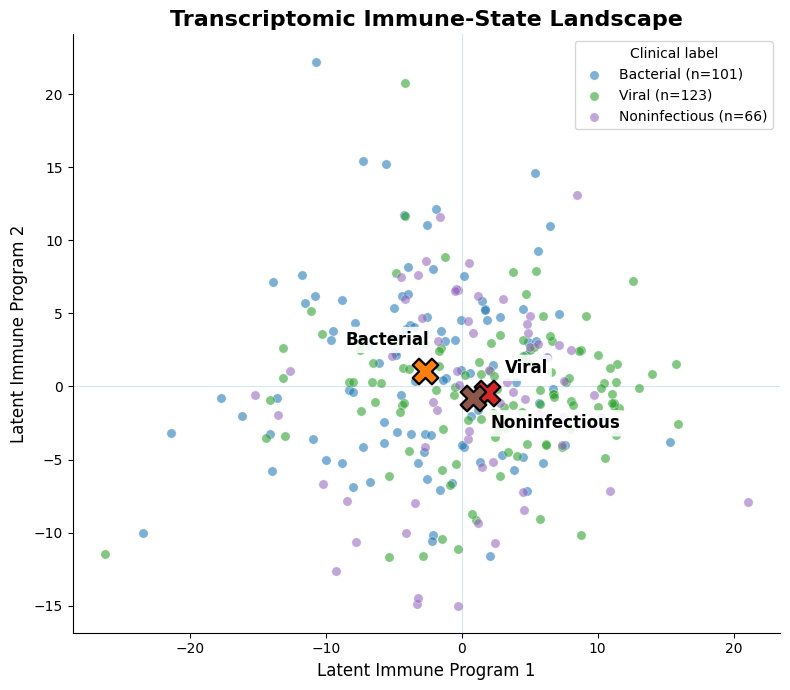

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_immune_state_landscape_FINAL_SAFE.png


In [124]:
# =====================================================
# CELL 23C FINAL SAFE
# Clean immune-state landscape: scatter + centroids only
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plot_df = pd.DataFrame({
    "PC1": state_landscape_df["PC1"],
    "PC2": state_landscape_df["PC2"],
    "label": y
}).dropna()

label_order = ["Bacterial", "Viral", "Noninfectious"]
label_order = [x for x in label_order if x in plot_df["label"].unique()]

fig, ax = plt.subplots(figsize=(8, 7))

centroids = {}

for lab in label_order:
    sub = plot_df[plot_df["label"] == lab]

    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=45,
        alpha=0.58,
        label=f"{lab} (n={len(sub)})",
        edgecolor="white",
        linewidth=0.4
    )

    cx = sub["PC1"].mean()
    cy = sub["PC2"].mean()
    centroids[lab] = (cx, cy)

    ax.scatter(
        cx,
        cy,
        s=340,
        marker="X",
        edgecolor="black",
        linewidth=1.6,
        zorder=6
    )

label_offsets = {
    "Bacterial": (-5.8, 1.8),
    "Viral": (1.3, 1.4),
    "Noninfectious": (1.3, -2.1)
}

for lab, (cx, cy) in centroids.items():
    dx, dy = label_offsets.get(lab, (1.2, 1.2))

    ax.text(
        cx + dx,
        cy + dy,
        lab,
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            alpha=0.88,
            edgecolor="none"
        ),
        zorder=7
    )

ax.axhline(0, linewidth=0.8, alpha=0.18)
ax.axvline(0, linewidth=0.8, alpha=0.18)

ax.set_title(
    "Transcriptomic Immune-State Landscape",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Latent Immune Program 1", fontsize=12)
ax.set_ylabel("Latent Immune Program 2", fontsize=12)

ax.legend(title="Clinical label", frameon=True, loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_immune_state_landscape_FINAL_SAFE.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

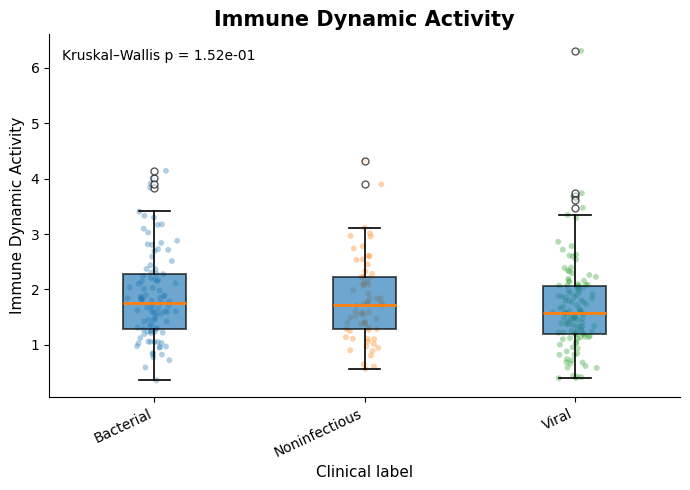

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_Immune_Dynamic_Activity_final.png


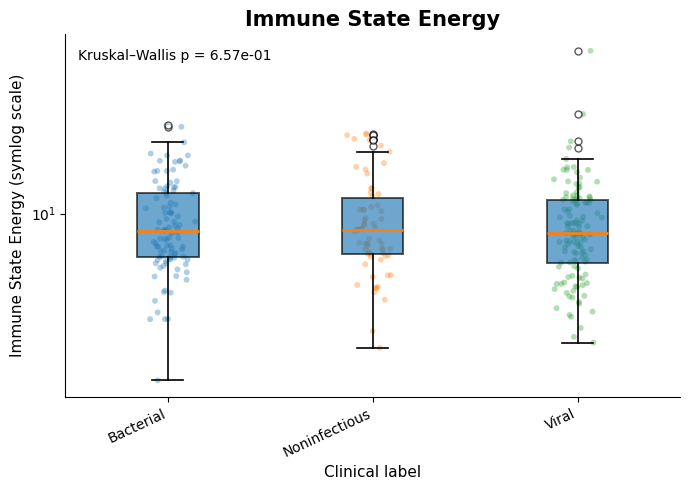

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_Immune_State_Energy_final.png


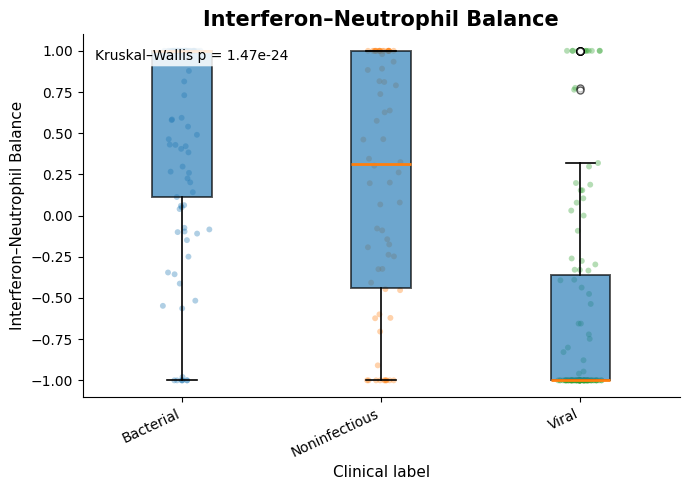

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_Interferon_Neutrophil_Balance_final.png


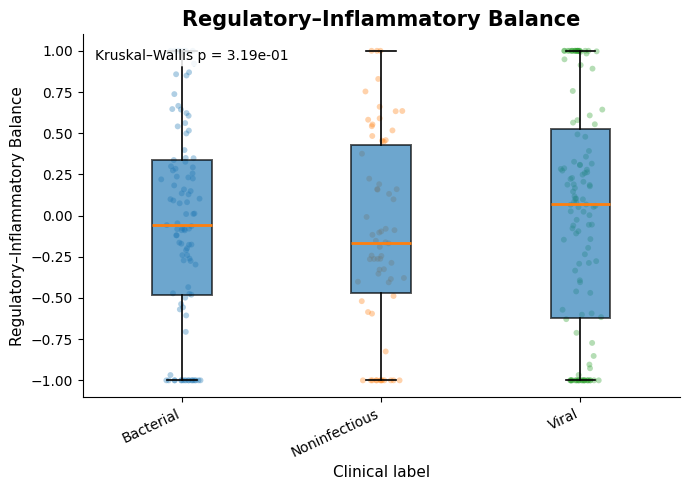

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_Regulatory_Inflammatory_Balance_final.png


In [118]:
# =====================================================
# CELL 24C FINAL
# Publication-quality mathematical immune indices
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import kruskal

plot_indices = [
    "Immune_Dynamic_Activity",
    "Immune_State_Energy",
    "Interferon_Neutrophil_Balance",
    "Regulatory_Inflammatory_Balance"
]

label_order = ["Bacterial", "Noninfectious", "Viral"]

pretty_titles = {
    "Immune_Dynamic_Activity": "Immune Dynamic Activity",
    "Immune_State_Energy": "Immune State Energy",
    "Interferon_Neutrophil_Balance": "Interferon–Neutrophil Balance",
    "Regulatory_Inflammatory_Balance": "Regulatory–Inflammatory Balance"
}

for col in plot_indices:
    data = [
        decision_df.loc[decision_df["label"] == lab, col].dropna().values
        for lab in label_order
    ]

    stat, pval = kruskal(*data)

    fig, ax = plt.subplots(figsize=(7, 5))

    box = ax.boxplot(
        data,
        labels=label_order,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(linewidth=2),
        boxprops=dict(linewidth=1.4),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="white",
            markeredgecolor="black",
            alpha=0.65
        )
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.65)

    # Overlay jittered individual points
    for i, vals in enumerate(data, start=1):
        jitter = np.random.normal(loc=i, scale=0.045, size=len(vals))
        ax.scatter(
            jitter,
            vals,
            s=18,
            alpha=0.35,
            edgecolor="none"
        )

    title = pretty_titles[col]
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel("Clinical label", fontsize=11)

    ax.text(
        0.02,
        0.96,
        f"Kruskal–Wallis p = {pval:.2e}",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            alpha=0.85,
            edgecolor="none"
        )
    )

    # Better scaling for Immune State Energy because of extreme outlier
    if col == "Immune_State_Energy":
        ax.set_yscale("symlog", linthresh=1)
        ax.set_ylabel("Immune State Energy (symlog scale)", fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    fig_path = os.path.join(FIG_DIR, f"fig_{col}_final.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)

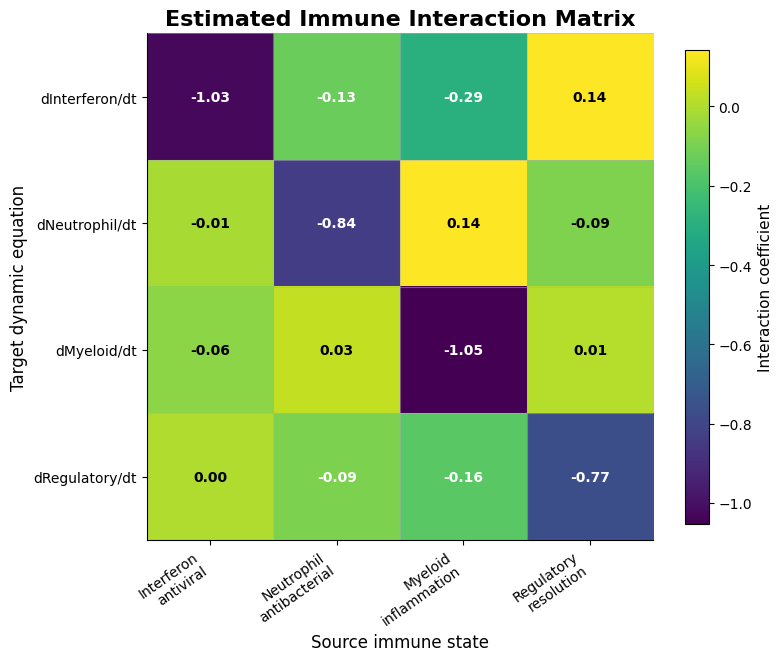

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_immune_interaction_matrix_final_annotated.png


In [120]:
# =====================================================
# CELL 25C FINAL
# Annotated immune interaction matrix heatmap
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
import os

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(A_df.values, aspect="equal")

cbar = plt.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Interaction coefficient", fontsize=11)

x_labels = [
    "Interferon\nantiviral",
    "Neutrophil\nantibacterial",
    "Myeloid\ninflammation",
    "Regulatory\nresolution"
]

y_labels = [
    "dInterferon/dt",
    "dNeutrophil/dt",
    "dMyeloid/dt",
    "dRegulatory/dt"
]

ax.set_xticks(np.arange(len(x_labels)))
ax.set_yticks(np.arange(len(y_labels)))

ax.set_xticklabels(x_labels, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(y_labels, fontsize=10)

# Cell annotations
for i in range(A_df.shape[0]):
    for j in range(A_df.shape[1]):
        value = A_df.values[i, j]
        text_color = "white" if value < np.nanmedian(A_df.values) else "black"
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=text_color
        )

# Gridlines
ax.set_xticks(np.arange(-0.5, A_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, A_df.shape[0], 1), minor=True)
ax.grid(which="minor", linewidth=0.8, alpha=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title(
    "Estimated Immune Interaction Matrix",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Source immune state", fontsize=12)
ax.set_ylabel("Target dynamic equation", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_immune_interaction_matrix_final_annotated.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

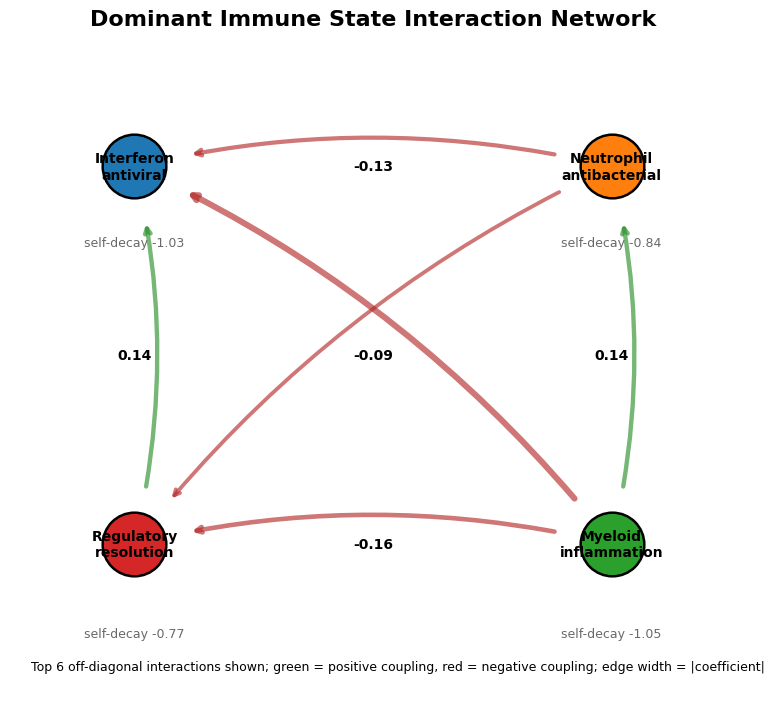

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_immune_interaction_network_FINAL_CLEAN.png


,source,target,coeff,abs_coeff
1,Myeloid_Inflammation,Interferon_Antiviral,-0.293731,0.293731
11,Myeloid_Inflammation,Regulatory_Resolution,-0.163438,0.163438
4,Myeloid_Inflammation,Neutrophil_Antibacterial,0.142810,0.142810
2,Regulatory_Resolution,Interferon_Antiviral,0.140915,0.140915
0,Neutrophil_Antibacterial,Interferon_Antiviral,-0.128128,0.128128
10,Neutrophil_Antibacterial,Regulatory_Resolution,-0.093813,0.093813


In [132]:
# =====================================================
# CELL 26A FINAL CLEAN
# Immune interaction network: top strongest interactions only
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

short_names = {
    "Interferon_Antiviral": "Interferon\nantiviral",
    "Neutrophil_Antibacterial": "Neutrophil\nantibacterial",
    "Myeloid_Inflammation": "Myeloid\ninflammation",
    "Regulatory_Resolution": "Regulatory\nresolution"
}

states = list(A_df.columns)

positions = {
    "Interferon_Antiviral": (-1.15, 0.85),
    "Neutrophil_Antibacterial": (1.15, 0.85),
    "Myeloid_Inflammation": (1.15, -0.85),
    "Regulatory_Resolution": (-1.15, -0.85)
}

# collect off-diagonal interactions
edges = []
for target_i, target_state in enumerate(states):
    for source_j, source_state in enumerate(states):
        coeff = A_df.iloc[target_i, source_j]
        if source_state != target_state:
            edges.append({
                "source": source_state,
                "target": target_state,
                "coeff": coeff,
                "abs_coeff": abs(coeff)
            })

edge_df = pd.DataFrame(edges)

# keep only strongest biologically meaningful interactions
edge_df = edge_df.sort_values("abs_coeff", ascending=False).head(6)

fig, ax = plt.subplots(figsize=(8.5, 7.2))

# draw edges first
for _, row in edge_df.iterrows():
    source = row["source"]
    target = row["target"]
    coeff = row["coeff"]

    x1, y1 = positions[source]
    x2, y2 = positions[target]

    color = "forestgreen" if coeff > 0 else "firebrick"
    width = 2.0 + 8.0 * abs(coeff)

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=width,
            color=color,
            alpha=0.62,
            shrinkA=42,
            shrinkB=42,
            connectionstyle="arc3,rad=0.12"
        ),
        zorder=1
    )

    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(
        mx,
        my,
        f"{coeff:.2f}",
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            alpha=0.88,
            edgecolor="none"
        ),
        zorder=3
    )

# draw nodes
for s in states:
    x, y0 = positions[s]
    ax.scatter(
        x,
        y0,
        s=2100,
        edgecolor="black",
        linewidth=1.8,
        zorder=4
    )
    ax.text(
        x,
        y0,
        short_names[s],
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        zorder=5
    )

# self-decay labels below nodes
for i, s in enumerate(states):
    x, y0 = positions[s]
    coeff = A_df.iloc[i, i]
    y_offset = -0.36 if y0 > 0 else -0.42
    ax.text(
        x,
        y0 + y_offset,
        f"self-decay {coeff:.2f}",
        ha="center",
        fontsize=9,
        color="dimgray",
        zorder=6
    )

ax.set_title(
    "Dominant Immune State Interaction Network",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    -1.65,
    -1.42,
    "Top 6 off-diagonal interactions shown; green = positive coupling, red = negative coupling; edge width = |coefficient|",
    fontsize=9
)

ax.set_xlim(-1.75, 1.75)
ax.set_ylim(-1.55, 1.45)
ax.axis("off")

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_immune_interaction_network_FINAL_CLEAN.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
display(edge_df)

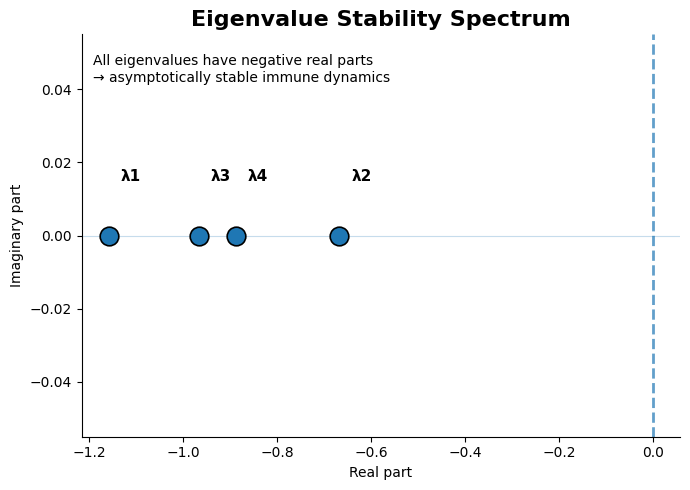

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_eigenvalue_stability_spectrum.png


In [128]:
# =====================================================
# CELL 26B
# Eigenvalue stability spectrum
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import os

eig_real = stability_df["eigenvalue_real"].values
eig_imag = stability_df["eigenvalue_imag"].values

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    eig_real,
    eig_imag,
    s=180,
    edgecolor="black",
    linewidth=1.2,
    zorder=4
)

for i, (xr, yi) in enumerate(zip(eig_real, eig_imag), start=1):
    ax.text(xr + 0.025, yi + 0.015, f"λ{i}", fontsize=11, fontweight="bold")

ax.axvline(0, linewidth=2, linestyle="--", alpha=0.7)
ax.axhline(0, linewidth=0.8, alpha=0.25)

ax.set_title("Eigenvalue Stability Spectrum", fontsize=16, fontweight="bold")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")

ax.text(
    0.02,
    0.95,
    "All eigenvalues have negative real parts\n→ asymptotically stable immune dynamics",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_eigenvalue_stability_spectrum.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

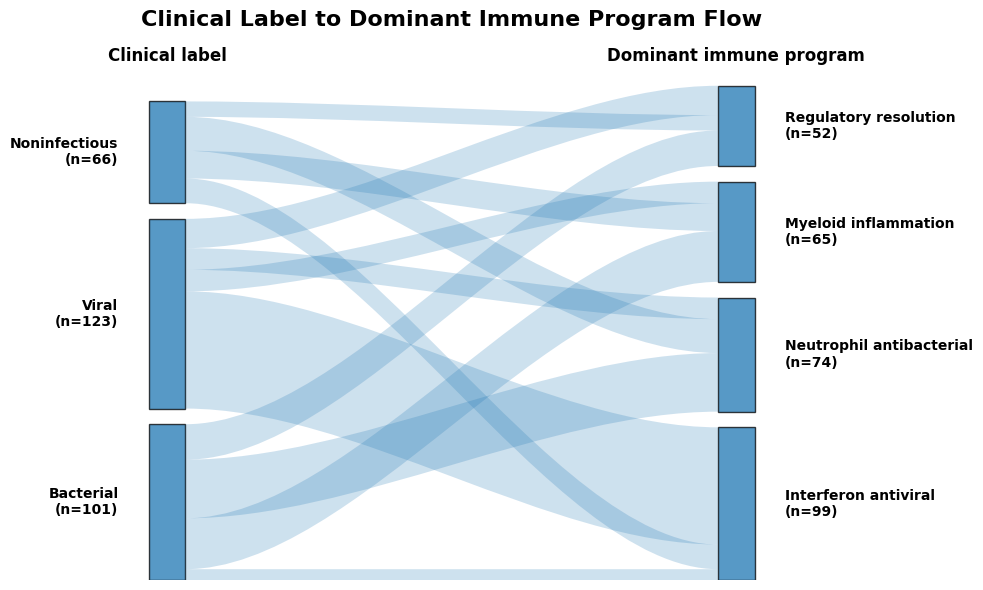

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_clinical_to_immune_program_flow.png


In [134]:
# =====================================================
# CELL 26C-EXTRA
# Alluvial flow: clinical label -> dominant immune program
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
import os

flow_df = immune_state_df[core_states + ["label"]].copy()

flow_df["Dominant_Immune_Program"] = flow_df[core_states].idxmax(axis=1)
flow_df["Dominant_Immune_Program"] = flow_df["Dominant_Immune_Program"].replace({
    "Interferon_Antiviral": "Interferon antiviral",
    "Neutrophil_Antibacterial": "Neutrophil antibacterial",
    "Myeloid_Inflammation": "Myeloid inflammation",
    "Regulatory_Resolution": "Regulatory resolution"
})

left_order = ["Bacterial", "Viral", "Noninfectious"]
left_order = [x for x in left_order if x in flow_df["label"].unique()]

right_order = [
    "Interferon antiviral",
    "Neutrophil antibacterial",
    "Myeloid inflammation",
    "Regulatory resolution"
]
right_order = [x for x in right_order if x in flow_df["Dominant_Immune_Program"].unique()]

counts = (
    flow_df.groupby(["label", "Dominant_Immune_Program"])
    .size()
    .reset_index(name="count")
)

total = counts["count"].sum()

left_totals = flow_df["label"].value_counts().reindex(left_order).fillna(0)
right_totals = flow_df["Dominant_Immune_Program"].value_counts().reindex(right_order).fillna(0)

def make_blocks(order, totals):
    y = 0
    blocks = {}
    gap = total * 0.035
    for name in order:
        h = totals[name]
        blocks[name] = (y, y + h)
        y += h + gap
    return blocks, y

left_blocks, left_height = make_blocks(left_order, left_totals)
right_blocks, right_height = make_blocks(right_order, right_totals)

max_height = max(left_height, right_height)

fig, ax = plt.subplots(figsize=(10, 6))

left_x = 0.15
right_x = 0.85
bar_w = 0.045

# Draw blocks
for name, (y0, y1) in left_blocks.items():
    ax.add_patch(Rectangle((left_x - bar_w/2, y0), bar_w, y1-y0, alpha=0.75, edgecolor="black"))
    ax.text(left_x - 0.06, (y0+y1)/2, f"{name}\n(n={int(y1-y0)})", ha="right", va="center", fontsize=10, fontweight="bold")

for name, (y0, y1) in right_blocks.items():
    ax.add_patch(Rectangle((right_x - bar_w/2, y0), bar_w, y1-y0, alpha=0.75, edgecolor="black"))
    ax.text(right_x + 0.06, (y0+y1)/2, f"{name}\n(n={int(y1-y0)})", ha="left", va="center", fontsize=10, fontweight="bold")

# Flow offsets
left_offsets = {k: v[0] for k, v in left_blocks.items()}
right_offsets = {k: v[0] for k, v in right_blocks.items()}

for _, row in counts.iterrows():
    l = row["label"]
    r = row["Dominant_Immune_Program"]
    c = row["count"]

    y0a = left_offsets[l]
    y0b = y0a + c
    left_offsets[l] += c

    y1a = right_offsets[r]
    y1b = y1a + c
    right_offsets[r] += c

    verts = [
        (left_x + bar_w/2, y0a),
        (0.38, y0a),
        (0.62, y1a),
        (right_x - bar_w/2, y1a),
        (right_x - bar_w/2, y1b),
        (0.62, y1b),
        (0.38, y0b),
        (left_x + bar_w/2, y0b),
        (left_x + bar_w/2, y0a)
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.LINETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.CLOSEPOLY
    ]

    patch = PathPatch(
        Path(verts, codes),
        alpha=0.22,
        edgecolor="none"
    )
    ax.add_patch(patch)

ax.set_title("Clinical Label to Dominant Immune Program Flow", fontsize=16, fontweight="bold")
ax.text(left_x, max_height + total*0.02, "Clinical label", ha="center", fontsize=12, fontweight="bold")
ax.text(right_x, max_height + total*0.02, "Dominant immune program", ha="center", fontsize=12, fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, max_height + total*0.08)
ax.axis("off")

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_clinical_to_immune_program_flow.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

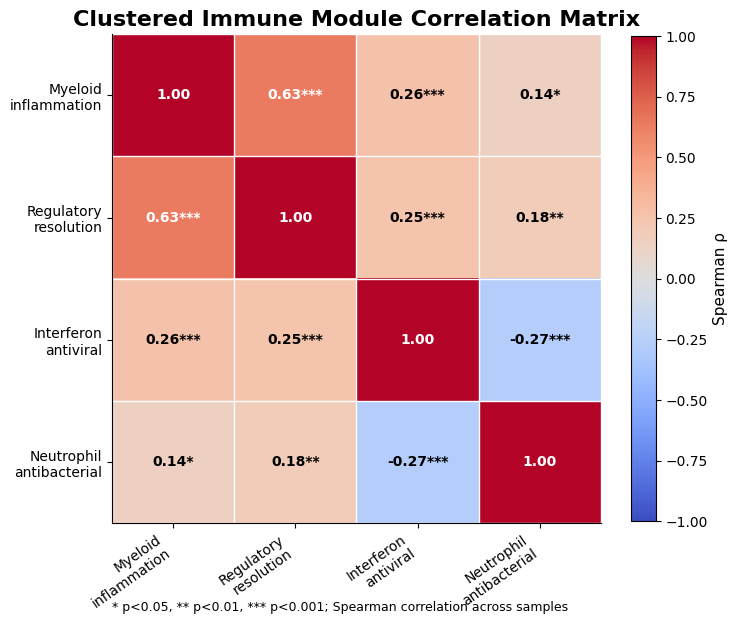

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_clustered_immune_module_correlation_heatmap.png
Saved correlation and p-value matrices.


In [138]:
# =====================================================
# CELL 26D FINAL
# Clustered immune module correlation heatmap
# Replace old correlation network
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# -----------------------------
# Input
# -----------------------------
corr_input = immune_state_df[core_states].copy()

pretty_names = {
    "Interferon_Antiviral": "Interferon\nantiviral",
    "Neutrophil_Antibacterial": "Neutrophil\nantibacterial",
    "Myeloid_Inflammation": "Myeloid\ninflammation",
    "Regulatory_Resolution": "Regulatory\nresolution"
}

# -----------------------------
# Spearman correlation + p-values
# -----------------------------
n = len(core_states)

corr_mat = pd.DataFrame(
    np.eye(n),
    index=core_states,
    columns=core_states
)

p_mat = pd.DataFrame(
    np.zeros((n, n)),
    index=core_states,
    columns=core_states
)

for i, g1 in enumerate(core_states):
    for j, g2 in enumerate(core_states):
        rho, pval = spearmanr(corr_input[g1], corr_input[g2])
        corr_mat.loc[g1, g2] = rho
        p_mat.loc[g1, g2] = pval

# -----------------------------
# Hierarchical clustering order
# -----------------------------
dist_mat = 1 - np.abs(corr_mat.values)
np.fill_diagonal(dist_mat, 0)

# make symmetric and valid condensed distance
dist_mat = (dist_mat + dist_mat.T) / 2
condensed_dist = squareform(dist_mat, checks=False)

link = linkage(condensed_dist, method="average")
order = leaves_list(link)

ordered_states = [core_states[i] for i in order]

corr_ord = corr_mat.loc[ordered_states, ordered_states]
p_ord = p_mat.loc[ordered_states, ordered_states]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.5, 6.8))

im = ax.imshow(
    corr_ord.values,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="equal"
)

cbar = plt.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Spearman ρ", fontsize=11)

x_labels = [pretty_names[x] for x in ordered_states]
y_labels = [pretty_names[x] for x in ordered_states]

ax.set_xticks(np.arange(len(ordered_states)))
ax.set_yticks(np.arange(len(ordered_states)))

ax.set_xticklabels(x_labels, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(y_labels, fontsize=10)

# annotations with significance stars
for i in range(len(ordered_states)):
    for j in range(len(ordered_states)):
        rho = corr_ord.iloc[i, j]
        pval = p_ord.iloc[i, j]

        if i == j:
            star = ""
        elif pval < 0.001:
            star = "***"
        elif pval < 0.01:
            star = "**"
        elif pval < 0.05:
            star = "*"
        else:
            star = ""

        txt = f"{rho:.2f}{star}"

        text_color = "white" if abs(rho) > 0.55 else "black"

        ax.text(
            j,
            i,
            txt,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=text_color
        )

# gridlines
ax.set_xticks(np.arange(-0.5, len(ordered_states), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ordered_states), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title(
    "Clustered Immune Module Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    0.0,
    -0.18,
    "* p<0.05, ** p<0.01, *** p<0.001; Spearman correlation across samples",
    transform=ax.transAxes,
    fontsize=9,
    ha="left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_clustered_immune_module_correlation_heatmap.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

corr_mat.to_csv(os.path.join(OUT_DIR, "immune_module_spearman_correlation_matrix.csv"))
p_mat.to_csv(os.path.join(OUT_DIR, "immune_module_spearman_pvalue_matrix.csv"))

print("Saved correlation and p-value matrices.")

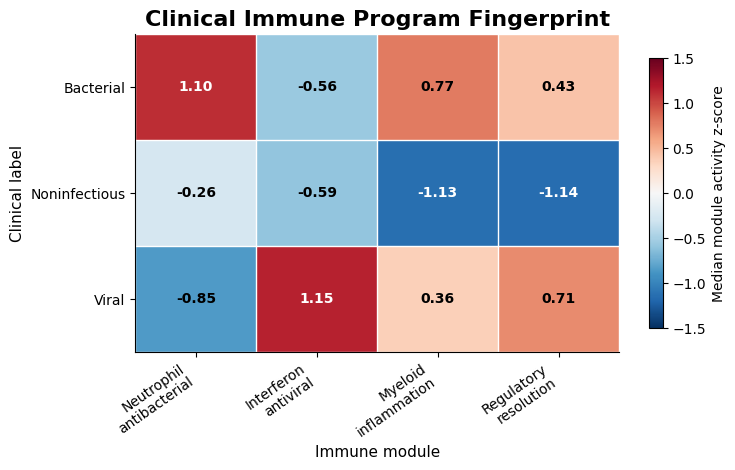

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_clinical_immune_program_fingerprint_heatmap.png


In [140]:
# =====================================================
# CELL 26E
# Immune program fingerprint heatmap by clinical label
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

label_order = ["Bacterial", "Noninfectious", "Viral"]
label_order = [x for x in label_order if x in immune_state_df["label"].unique()]

pretty_module_names = {
    "Interferon_Antiviral": "Interferon\nantiviral",
    "Neutrophil_Antibacterial": "Neutrophil\nantibacterial",
    "Myeloid_Inflammation": "Myeloid\ninflammation",
    "Regulatory_Resolution": "Regulatory\nresolution"
}

fingerprint = (
    immune_state_df
    .groupby("label")[core_states]
    .median()
    .loc[label_order]
)

# Z-score per module across clinical labels for clearer fingerprint contrast
fingerprint_z = fingerprint.copy()
for col in fingerprint_z.columns:
    sd = fingerprint_z[col].std()
    if sd == 0 or np.isnan(sd):
        fingerprint_z[col] = 0
    else:
        fingerprint_z[col] = (fingerprint_z[col] - fingerprint_z[col].mean()) / sd

# cluster modules only
module_dist = pdist(fingerprint_z.T.values, metric="euclidean")
module_link = linkage(module_dist, method="average")
module_order = leaves_list(module_link)
ordered_modules = [core_states[i] for i in module_order]

plot_mat = fingerprint_z[ordered_modules]

fig, ax = plt.subplots(figsize=(7.6, 4.8))

im = ax.imshow(
    plot_mat.values,
    cmap="RdBu_r",
    vmin=-1.5,
    vmax=1.5,
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Median module activity z-score", fontsize=10)

ax.set_xticks(np.arange(len(ordered_modules)))
ax.set_yticks(np.arange(len(label_order)))

ax.set_xticklabels(
    [pretty_module_names[x] for x in ordered_modules],
    rotation=35,
    ha="right",
    fontsize=10
)
ax.set_yticklabels(label_order, fontsize=10)

for i in range(plot_mat.shape[0]):
    for j in range(plot_mat.shape[1]):
        val = plot_mat.iloc[i, j]
        color = "white" if abs(val) > 0.9 else "black"
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=color
        )

ax.set_title(
    "Clinical Immune Program Fingerprint",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Immune module", fontsize=11)
ax.set_ylabel("Clinical label", fontsize=11)

ax.set_xticks(np.arange(-0.5, plot_mat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_mat.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_clinical_immune_program_fingerprint_heatmap.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

fingerprint.to_csv(os.path.join(OUT_DIR, "clinical_immune_program_fingerprint_median.csv"))
fingerprint_z.to_csv(os.path.join(OUT_DIR, "clinical_immune_program_fingerprint_zscore.csv"))

print("Saved:", fig_path)

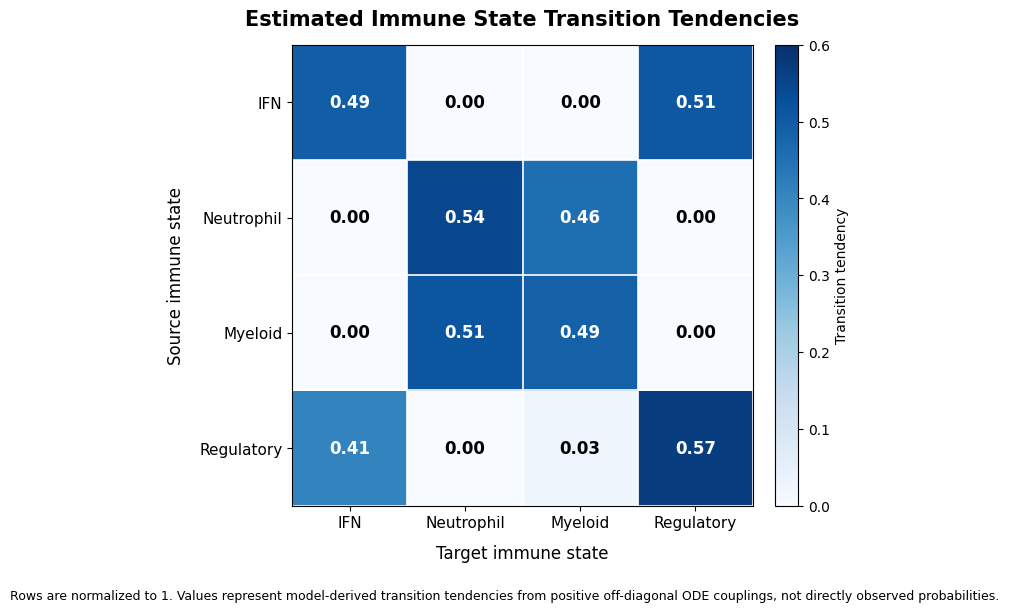

Saved: /Users/rifaldyfajar/GSE211567_LMCE_Project/outputs/figures/fig_immune_state_transition_tendencies_FINAL_FIXED.png


,Interferon_Antiviral,Neutrophil_Antibacterial,Myeloid_Inflammation,Regulatory_Resolution
Interferon_Antiviral,0.493627,0.000000,0.000000,0.506373
Neutrophil_Antibacterial,0.000000,0.544900,0.455100,0.000000
Myeloid_Inflammation,0.000000,0.512617,0.487383,0.000000
Regulatory_Resolution,0.405723,0.000000,0.028120,0.566157


In [148]:
# =====================================================
# CELL 26G FINAL FIXED
# Clean immune state transition tendency matrix
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

states = list(A_df.columns)

short_labels = {
    "Interferon_Antiviral": "IFN",
    "Neutrophil_Antibacterial": "Neutrophil",
    "Myeloid_Inflammation": "Myeloid",
    "Regulatory_Resolution": "Regulatory"
}

transition = pd.DataFrame(0.0, index=states, columns=states)

for source in states:
    targets_no_self = [t for t in states if t != source]
    outgoing_positive = []

    for target in targets_no_self:
        coeff = A_df.loc[f"d{target}/dt", source]
        outgoing_positive.append(max(coeff, 0))

    outgoing_positive = np.array(outgoing_positive, dtype=float)

    source_idx = states.index(source)
    self_decay = abs(A_df.iloc[source_idx, source_idx])
    self_retention = 1 / (1 + self_decay)

    if outgoing_positive.sum() > 0:
        remaining = 1 - self_retention
        probs = remaining * outgoing_positive / outgoing_positive.sum()

        for target, p in zip(targets_no_self, probs):
            transition.loc[source, target] = p

    transition.loc[source, source] = self_retention

transition = transition.div(transition.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7.2, 6.2))

im = ax.imshow(
    transition.values,
    vmin=0,
    vmax=0.60,
    cmap="Blues",
    aspect="equal"
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Transition tendency", fontsize=10)

ax.set_xticks(np.arange(len(states)))
ax.set_yticks(np.arange(len(states)))

ax.set_xticklabels([short_labels[s] for s in states], fontsize=11)
ax.set_yticklabels([short_labels[s] for s in states], fontsize=11)

for i in range(len(states)):
    for j in range(len(states)):
        val = transition.iloc[i, j]
        color = "white" if val >= 0.35 else "black"
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=color
        )

ax.set_title(
    "Estimated Immune State Transition Tendencies",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Target immune state", fontsize=12, labelpad=10)
ax.set_ylabel("Source immune state", fontsize=12, labelpad=10)

ax.set_xticks(np.arange(-0.5, len(states), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(states), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

caption = (
    "Rows are normalized to 1. Values represent model-derived transition tendencies "
    "from positive off-diagonal ODE couplings, not directly observed probabilities."
)

fig.text(
    0.5,
    0.02,
    caption,
    ha="center",
    va="bottom",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

fig_path = os.path.join(FIG_DIR, "fig_immune_state_transition_tendencies_FINAL_FIXED.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

transition.to_csv(os.path.join(OUT_DIR, "immune_state_transition_tendencies_matrix.csv"))

print("Saved:", fig_path)
display(transition)

In [152]:
# =====================================================
# CELL 26C FINAL SUMMARY FIXED
# Final LMCE mathematical modeling summary
# =====================================================

import os
import numpy as np
import pandas as pd

# -----------------------------
# Safety checks
# -----------------------------
required_vars = ["meta_use", "A_df", "core_states", "stability_df", "immune_state_df", "OUT_DIR"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    raise NameError(
        "Missing required variables: "
        + ", ".join(missing)
        + "\nRun previous cells first: metadata matching, immune modules, ODE matrix, and stability analysis."
    )

# -----------------------------
# Basic sample information
# -----------------------------
n_samples = len(meta_use)

if "label" in meta_use.columns:
    label_series = meta_use["label"]
elif "label" in immune_state_df.columns:
    label_series = immune_state_df["label"]
else:
    raise KeyError("No label column found in meta_use or immune_state_df.")

class_counts = label_series.value_counts().to_dict()

# -----------------------------
# Rebuild interaction/sensitivity table from A_df
# -----------------------------
states = list(A_df.columns)

interaction_records = []

for target_i, target_state in enumerate(states):
    for source_j, source_state in enumerate(states):
        coeff = float(A_df.iloc[target_i, source_j])

        interaction_records.append({
            "source_module": source_state,
            "target_module": target_state,
            "coefficient": coeff,
            "absolute_coefficient": abs(coeff),
            "interaction_type": "self-regulation" if source_state == target_state else (
                "positive coupling" if coeff > 0 else "negative coupling"
            )
        })

interaction_df = (
    pd.DataFrame(interaction_records)
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

offdiag_df = interaction_df[
    interaction_df["source_module"] != interaction_df["target_module"]
].copy()

top_interactions = offdiag_df.head(10)

# -----------------------------
# Rebuild eigenvalue summary if needed
# -----------------------------
if not {"eigenvalue_real", "eigenvalue_imag", "magnitude"}.issubset(stability_df.columns):
    eigvals = np.linalg.eigvals(A_df.values)
    stability_df = pd.DataFrame({
        "eigenvalue_real": np.real(eigvals),
        "eigenvalue_imag": np.imag(eigvals),
        "magnitude": np.abs(eigvals)
    })
    stability_df["stable_component"] = stability_df["eigenvalue_real"] < 0

all_stable = bool((stability_df["eigenvalue_real"] < 0).all())

# -----------------------------
# Immune module medians by class
# -----------------------------
immune_medians = (
    immune_state_df
    .groupby("label")[core_states]
    .median()
)

# -----------------------------
# Optional: use decision_df if available
# -----------------------------
decision_summary_text = "Decision indices not available in current workspace."

if "decision_df" in globals():
    metric_cols = [
        c for c in [
            "Immune_Dynamic_Activity",
            "Immune_State_Energy",
            "Interferon_Neutrophil_Balance",
            "Regulatory_Inflammatory_Balance",
            "Energy_Landscape"
        ]
        if c in decision_df.columns
    ]

    if metric_cols and "label" in decision_df.columns:
        decision_summary = (
            decision_df
            .groupby("label")[metric_cols]
            .agg(["mean", "std", "median"])
        )
        decision_summary_text = decision_summary.to_string()
    else:
        decision_summary_text = "decision_df exists, but expected metric columns were not found."

# -----------------------------
# Optional: correlation matrix if available or rebuild
# -----------------------------
corr_mat = immune_state_df[core_states].corr(method="spearman")

# -----------------------------
# Final text summary
# -----------------------------
final_summary = f"""
============================================================
FINAL LMCE MATHEMATICAL MODELING SUMMARY
============================================================

PROJECT TITLE
Mathematical State-Space Modeling of Whole-Blood Transcriptomics
Characterizes Stable Immune Dynamics for Laboratory Decision Support
in Febrile Illness

DATASET
GSE211567 whole-blood RNA-seq

FINAL ANALYTIC SAMPLE SIZE
n = {n_samples}

CLASS DISTRIBUTION
{pd.Series(class_counts).to_string()}

CORE IMMUNE MODULES
{pd.Series(core_states).to_string(index=False)}

MODELING FRAMEWORK
1. RefSeq-to-gene-symbol transcriptome processing
2. Clinical metadata harmonization
3. Knowledge-guided immune module construction
4. Low-dimensional immune-state representation
5. Linear Ordinary Differential Equations (ODE) state-space modeling
6. Ridge-regularized estimation of immune interaction coefficients
7. Stability analysis using eigenvalues of the estimated linear ODE system
8. Immune fingerprint, correlation, and laboratory decision index analysis

ODE MODEL DESCRIPTION
The final mathematical model is a linear state-space ODE model.
The immune state vector contains four module-level activities:
interferon-antiviral, neutrophil-antibacterial, myeloid-inflammatory,
and regulatory-resolution responses.

The estimated interaction matrix A describes inferred relationships among
these immune modules. Negative diagonal coefficients represent estimated
self-regulation. Off-diagonal coefficients represent estimated cross-module
coupling. The model should be interpreted as an inferred transcriptomic
state-space model, not as a directly observed longitudinal kinetic model.

ESTIMATED IMMUNE INTERACTION MATRIX A
{A_df.to_string()}

TOP OFF-DIAGONAL IMMUNE INTERACTIONS
{top_interactions.to_string(index=False)}

STABILITY RESULTS
All eigenvalue real parts negative: {all_stable}

Eigenvalue table:
{stability_df.to_string(index=False)}

IMMUNE MODULE MEDIANS BY CLINICAL LABEL
{immune_medians.to_string()}

SPEARMAN MODULE CORRELATION MATRIX
{corr_mat.to_string()}

LABORATORY DECISION INDEX SUMMARY
{decision_summary_text}

INTERPRETATION
This analysis reframes whole-blood host-response transcriptomics as an
inferred immune state-space system rather than a simple diagnostic
classification task. The model estimates interactions among interferon,
neutrophil, myeloid, and regulatory immune programs and evaluates whether
the inferred system is dynamically stable. The results support a clinically
interpretable mathematical framework for studying host-response patterns in
bacterial, viral, and noninfectious febrile illness.

CAUTION FOR REPORTING
The ODE model is linear and inferred from transcriptomic state
representations. It should be described as an estimated or inferred
immune-state model, not as a directly observed longitudinal immune kinetic
model.
============================================================
"""

# -----------------------------
# Save outputs
# -----------------------------
summary_path = os.path.join(OUT_DIR, "final_lmce_mathematical_modeling_summary.txt")
interaction_path = os.path.join(OUT_DIR, "final_lmce_interaction_coefficients.csv")
offdiag_path = os.path.join(OUT_DIR, "final_lmce_top_offdiagonal_interactions.csv")
corr_path = os.path.join(OUT_DIR, "final_lmce_module_spearman_correlation.csv")
median_path = os.path.join(OUT_DIR, "final_lmce_immune_module_medians_by_label.csv")

with open(summary_path, "w") as f:
    f.write(final_summary)

interaction_df.to_csv(interaction_path, index=False)
top_interactions.to_csv(offdiag_path, index=False)
corr_mat.to_csv(corr_path)
immune_medians.to_csv(median_path)

print(final_summary)
print("\nSaved summary:", summary_path)
print("Saved interaction coefficients:", interaction_path)
print("Saved top off-diagonal interactions:", offdiag_path)
print("Saved Spearman correlation matrix:", corr_path)
print("Saved immune module medians:", median_path)


FINAL LMCE MATHEMATICAL MODELING SUMMARY

PROJECT TITLE
Mathematical State-Space Modeling of Whole-Blood Transcriptomics
Characterizes Stable Immune Dynamics for Laboratory Decision Support
in Febrile Illness

DATASET
GSE211567 whole-blood RNA-seq

FINAL ANALYTIC SAMPLE SIZE
n = 290

CLASS DISTRIBUTION
Viral            123
Bacterial        101
Noninfectious     66

CORE IMMUNE MODULES
    Interferon_Antiviral
Neutrophil_Antibacterial
    Myeloid_Inflammation
   Regulatory_Resolution

MODELING FRAMEWORK
1. RefSeq-to-gene-symbol transcriptome processing
2. Clinical metadata harmonization
3. Knowledge-guided immune module construction
4. Low-dimensional immune-state representation
5. Linear Ordinary Differential Equations (ODE) state-space modeling
6. Ridge-regularized estimation of immune interaction coefficients
7. Stability analysis using eigenvalues of the estimated linear ODE system
8. Immune fingerprint, correlation, and laboratory decision index analysis

ODE MODEL DESCRIPTION
The